# Adversarial and Privacy Reinforced Credit Card Fraud Detection on MLP

**Names : Charline HUANGFU, Alexandre MARTEL**

This project aims to develop a trustworthy machine learning pipeline for Credit Card Fraud Detection. In the financial sector, a model's value is not only measured by its accuracy but also by its resilience to attacks, its respect for data privacy, and its ethical fairness.

Throughout this notebook, we implement and evaluate a Multi-Layer Perceptron (MLP) across three critical dimensions:


1.   **Adversarial Robustness:** We simulate evasion attempts using the **Fast Gradient Sign Method (FGSM)** and defend the model through **Adversarial Training**.
2.   **Data Privacy:** We assess the risk of data leakage via **Membership Inference Attacks (MIA)** and implement **Differential Privacy (DP-SGD)** as a defense mechanism.
3. **Fairness & Bias:** We analyze potential biases regarding transaction amounts and apply **Reweighing** techniques to ensure equitable model performance.



## Setup

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display
import os

In [3]:
!pip install -r requirements.txt

  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)


In [4]:
!python -m src.utils -d

Extracting files...
Downloaded to : C:\Users\charl\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3
File copied to : data\creditcard.csv



  0%|          | 0.00/66.0M [00:00<?, ?B/s]
  2%|▏         | 1.00M/66.0M [00:00<00:38, 1.76MB/s]
  3%|▎         | 2.00M/66.0M [00:00<00:22, 2.98MB/s]
  5%|▍         | 3.00M/66.0M [00:00<00:15, 4.15MB/s]
  6%|▌         | 4.00M/66.0M [00:01<00:13, 4.77MB/s]
  8%|▊         | 5.00M/66.0M [00:01<00:11, 5.58MB/s]
  9%|▉         | 6.00M/66.0M [00:01<00:10, 5.96MB/s]
 11%|█         | 7.00M/66.0M [00:01<00:10, 5.83MB/s]
 12%|█▏        | 8.00M/66.0M [00:01<00:09, 6.46MB/s]
 15%|█▌        | 10.0M/66.0M [00:01<00:06, 8.39MB/s]
 17%|█▋        | 11.0M/66.0M [00:01<00:06, 8.52MB/s]
 18%|█▊        | 12.0M/66.0M [00:02<00:06, 8.24MB/s]
 21%|██        | 14.0M/66.0M [00:02<00:06, 8.64MB/s]
 23%|██▎       | 15.0M/66.0M [00:02<00:06, 8.73MB/s]
 26%|██▌       | 17.0M/66.0M [00:02<00:05, 8.61MB/s]
 27%|██▋       | 18.0M/66.0M [00:02<00:06, 7.68MB/s]
 29%|██▉       | 19.0M/66.0M [00:03<00:06, 7.66MB/s]
 30%|███       | 20.0M/66.0M [00:03<00:07, 6.36MB/s]
 32%|███▏      | 21.0M/66.0M [00:03<00:07, 6.50MB/s]
 

## Dataset Exploratory Analysis

We will use the Credit Card Fraud Detection dataset from Kaggle, which contains transactions made by European cardholders in September 2013.

The dataset consists primarily of numerical features derived from a Principal Component Analysis (PCA) transformation. Due to confidentiality constraints, the original features and specific domain background are unavailable. Consequently, features V1 through V28 represent the principal components, while 'Time' and 'Amount' are the only variables retained in their original, non-transformed state.


In [40]:
csv_path = "/content/adversarial-privacy-fraud-detection/data/creditcard.csv"
df = pd.read_csv(csv_path)

In [10]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

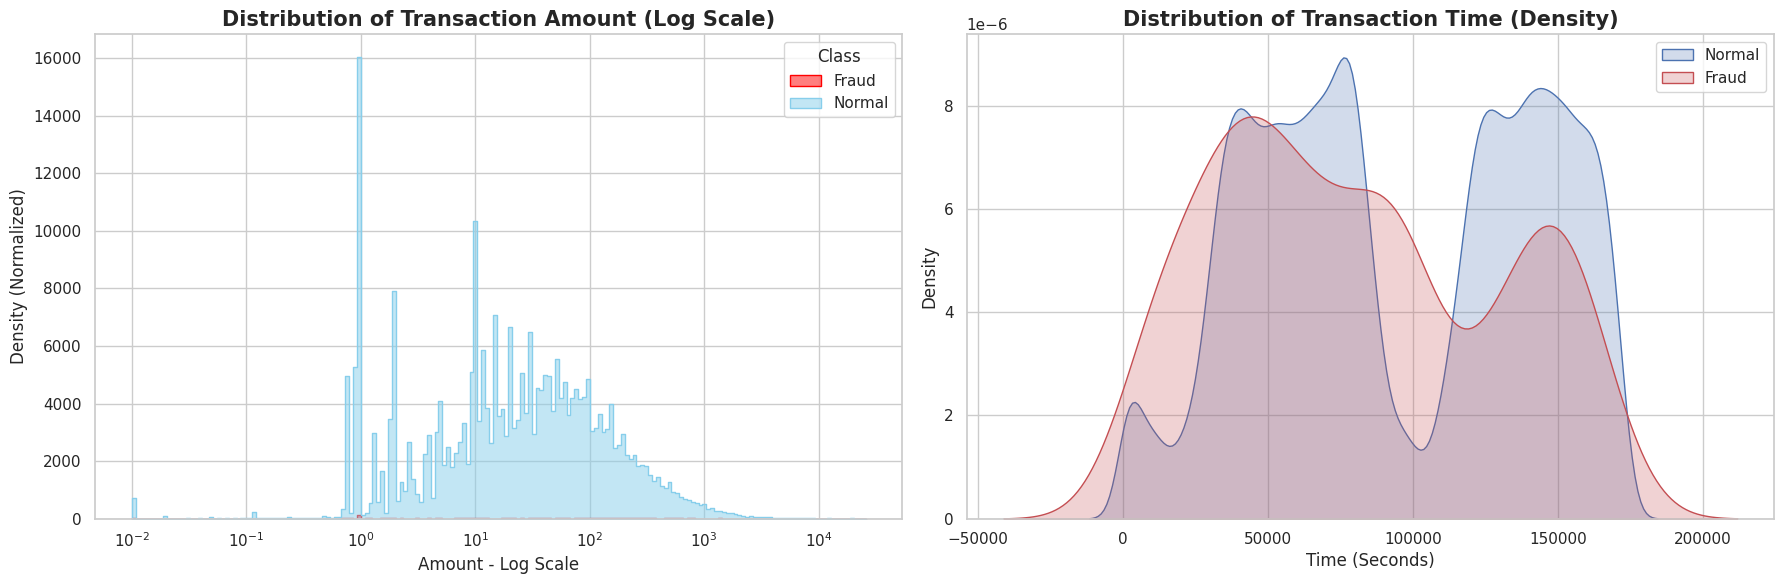

In [23]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(data=df, x='Amount', hue='Class', element="step", common_norm=False,
             palette={0: 'skyblue', 1: 'red'}, alpha=0.5, ax=ax[0], log_scale=True)

ax[0].set_title('Distribution of Transaction Amount (Log Scale)', fontsize=15, fontweight='bold')
ax[0].set_xlabel('Amount - Log Scale')
ax[0].set_ylabel('Density (Normalized)')
ax[0].legend(title='Class', labels=['Fraud', 'Normal'])

sns.kdeplot(data=df[df['Class'] == 0]['Time'], label='Normal', color='b', fill=True, ax=ax[1])
sns.kdeplot(data=df[df['Class'] == 1]['Time'], label='Fraud', color='r', fill=True, ax=ax[1])

ax[1].set_title('Distribution of Transaction Time (Density)', fontsize=15, fontweight='bold')
ax[1].set_xlabel('Time (Seconds)')
ax[1].set_ylabel('Density')
ax[1].legend()

plt.tight_layout()
plt.show()

No Frauds: 284315 (99.83% of the dataset)
Frauds: 492 (0.17% of the dataset)


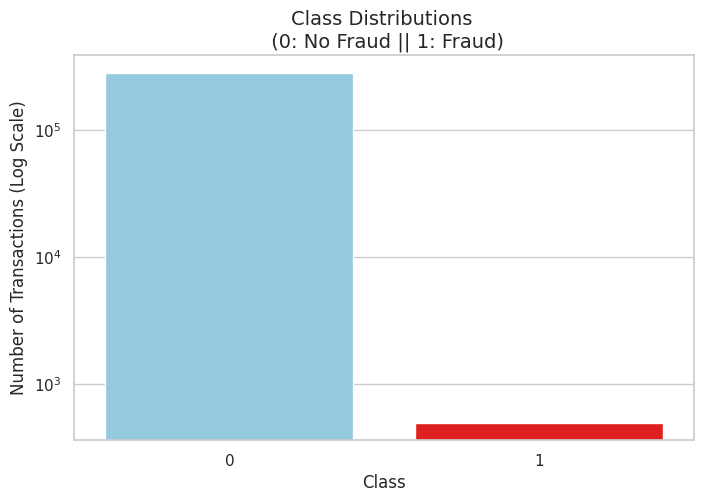

In [32]:
counts = df['Class'].value_counts()
n_total = len(df)
print(f"No Frauds: {counts[0]} ({round(counts[0]/n_total * 100, 2)}% of the dataset)")
print(f"Frauds: {counts[1]} ({round(counts[1]/n_total * 100, 2)}% of the dataset)")

plot_df = counts.reset_index()
plot_df.columns = ['Class', 'Count']

plt.figure(figsize=(8, 5))
sns.barplot(
    data=plot_df,
    x='Class',
    y='Count',
    hue='Class',
    palette={0: "skyblue", 1: "red"},
    legend=False
)

plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)')
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Transactions (Log Scale)')
plt.yscale('log')

plt.show()

The Preliminary Exploratory Data Analysis reveals a severe class imbalance within the dataset: only 492 transactions (0.17%) are identified as fraudulent out of a total of 284 807.

This extreme imbalance is the core technical challenge of the project  :      
- **Adversarial:** The decision boundary for the "Fraud" class is extremely fragile. Because the model sees so few examples, a tiny perturbation (FGSM) can easily "push" a fraud sample into the "Normal" zone.
- **Privacy:** Rare samples are unique fingerprints. In a dataset of 284k, the 492 frauds are outliers. This makes them much easier for an attacker to identify via Membership Inference, as the model overfits more easily on rare data.
- **Bias:** It creates a Majority Class Bias. Without mitigation, the model will simply predict "Normal" for everything to achieve 99.8% accuracy, completely failing its purpose.

## Data Preprocessing

## Baseline MLP

In [ ]:
!python -m src.baselines.baseline_mlp 

Epoch 01 | train loss: 0.55986 | val PR-AUC: 0.7684
Epoch 02 | train loss: 0.30587 | val PR-AUC: 0.7738
Epoch 03 | train loss: 0.26980 | val PR-AUC: 0.7859
Epoch 04 | train loss: 0.22689 | val PR-AUC: 0.7955
Epoch 05 | train loss: 0.18451 | val PR-AUC: 0.7967
Epoch 06 | train loss: 0.20191 | val PR-AUC: 0.8124
Epoch 07 | train loss: 0.14704 | val PR-AUC: 0.8138
Epoch 08 | train loss: 0.14037 | val PR-AUC: 0.8138
Epoch 09 | train loss: 0.12568 | val PR-AUC: 0.8145
Epoch 10 | train loss: 0.11106 | val PR-AUC: 0.8104

=== Baseline MLP - Validation ===
Accuracy             : 0.9796179909413293
Precision (weighted) : 0.9982267001425034
Recall (weighted)    : 0.9796179909413293
F1-score (weighted)  : 0.9882008191201307
Precision (macro)    : 0.5361511231103759
Recall (macro)       : 0.9444158447816362
F1-score (macro)     : 0.5619578980864647
ROC-AUC              : 0.9804511534634814
PR-AUC (pos)         : 0.8104002746575198

Classification report:
               precision    recall  f1-scor

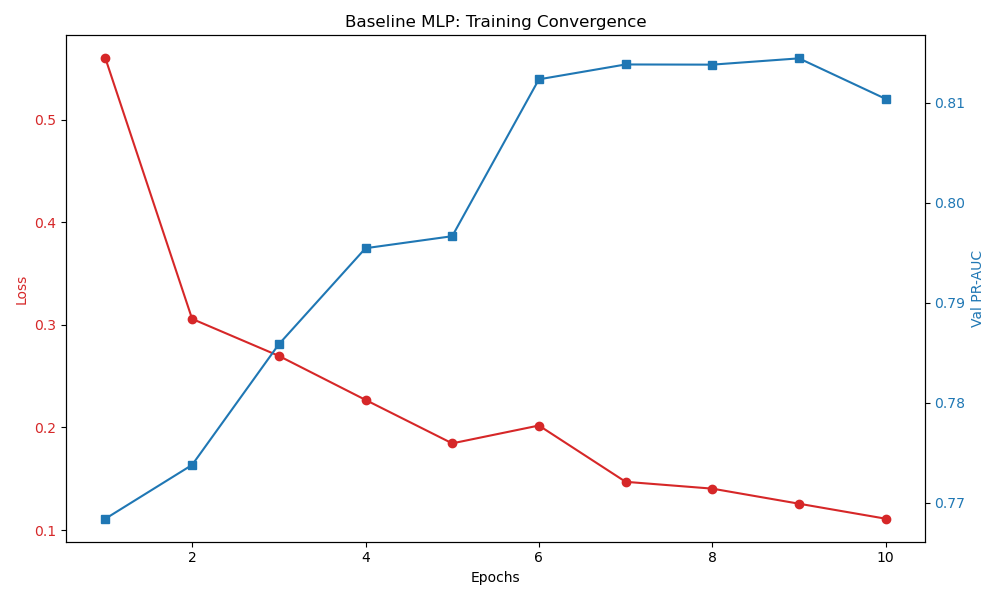

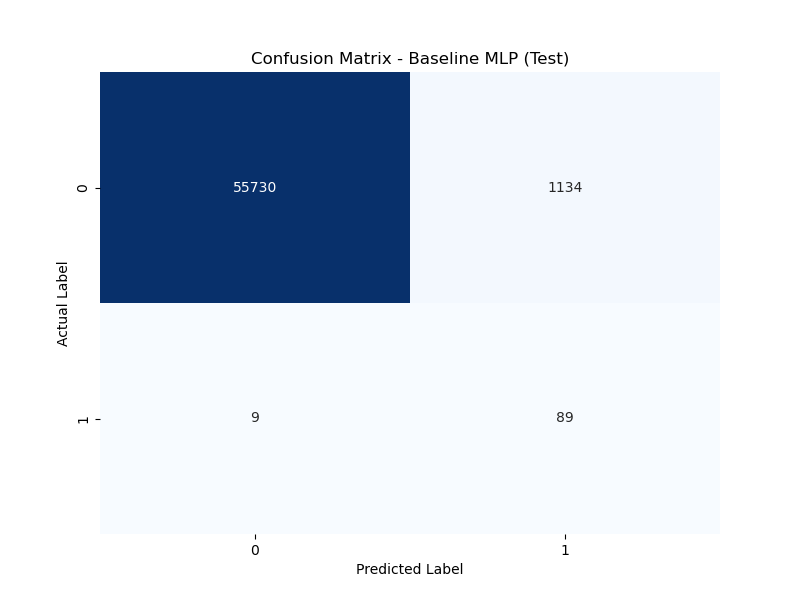

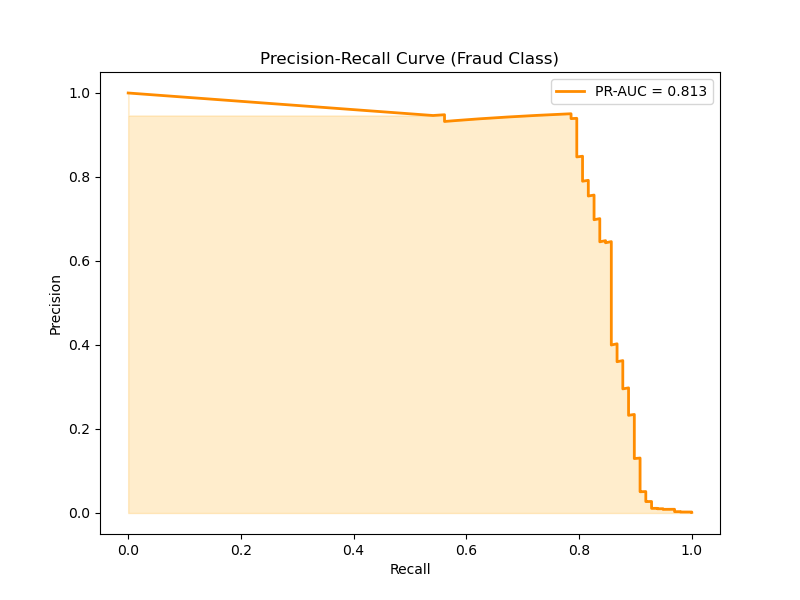

In [ ]:
display(Image(filename='baseline_model/learning_curves.png'))
display(Image(filename='baseline_model/confusion_matrix.png'))
display(Image(filename='baseline_model/pr_curve.png'))

## Adversarial Robustness (Security)

### The Attack : Fast Gradient Sign Method (FGSM)

In [22]:
!python -m src.adversarial.fsgm_attack


=== MLP - Test (avant attaque) ===
Accuracy             : 0.9799339910817738
Precision (weighted) : 0.9982435657685566
Recall (weighted)    : 0.9799339910817738
F1-score (weighted)  : 0.9883781358665298
Precision (macro)    : 0.536305202804151
Recall (macro)       : 0.9441104733958863
F1-score (macro)     : 0.5622978488874545
ROC-AUC              : 0.9718694191942393
PR-AUC (pos)         : 0.8131557834538906

Classification report:
               precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     56864
         1.0       0.07      0.91      0.13        98

    accuracy                           0.98     56962
   macro avg       0.54      0.94      0.56     56962
weighted avg       1.00      0.98      0.99     56962

Confusion matrix:
 [[55730  1134]
 [    9    89]]

=== MLP - Test (FGSM, eps=0.1) ===
Accuracy             : 0.9337804150135178
Precision (weighted) : 0.9981117071919714
Recall (weighted)    : 0.9337804150135178
F1-score (weighted)  : 

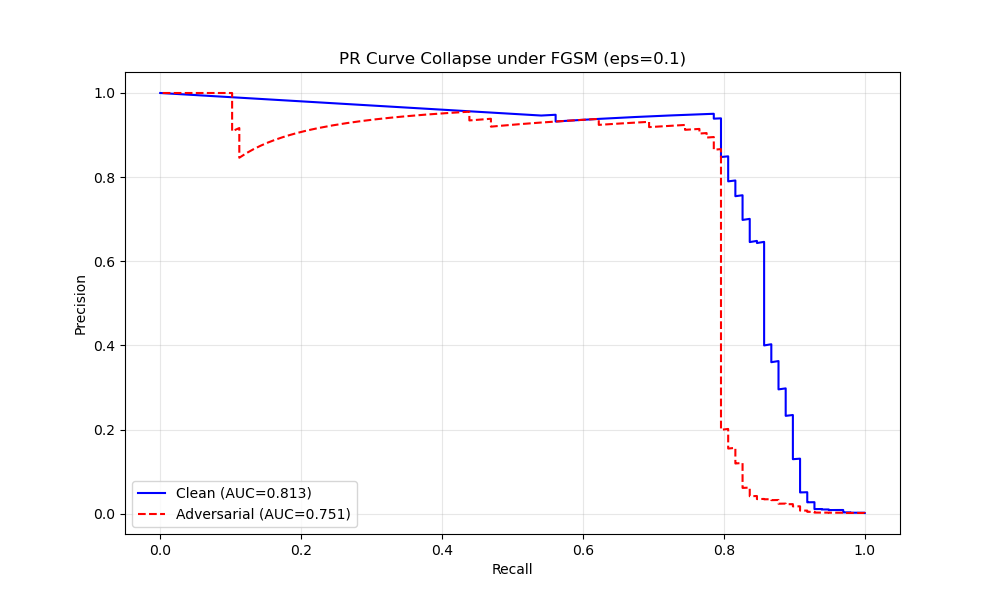

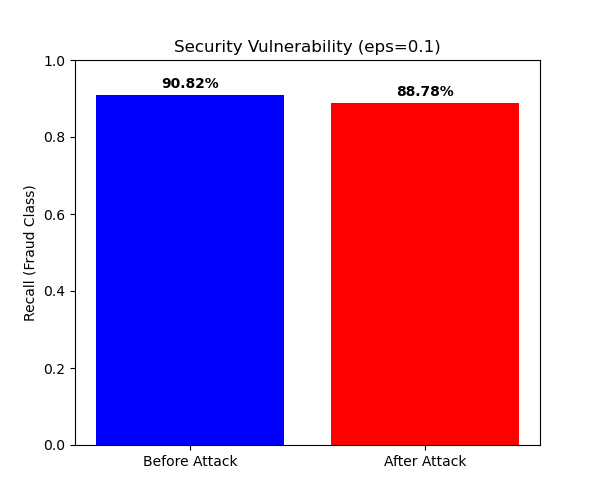

In [15]:
display(Image(filename='attack_results/attack_pr_comparison.png'))
display(Image(filename='attack_results/recall_drop.png'))

### The Defense : Advertial Traning

In [19]:
!python -m src.adversarial.adversarial_training --epsilon 0.1 --mix-ratio 0.5 --epochs 10

Epoch 01 | train loss: 0.57868 | val PR-AUC: 0.6765
Epoch 02 | train loss: 0.36222 | val PR-AUC: 0.6808
Epoch 03 | train loss: 0.32364 | val PR-AUC: 0.6939
Epoch 04 | train loss: 0.29614 | val PR-AUC: 0.6809
Epoch 05 | train loss: 0.25667 | val PR-AUC: 0.6994
Epoch 06 | train loss: 0.26675 | val PR-AUC: 0.6969
Epoch 07 | train loss: 0.18687 | val PR-AUC: 0.6998
Epoch 08 | train loss: 0.28575 | val PR-AUC: 0.7017
Epoch 09 | train loss: 0.22534 | val PR-AUC: 0.6919
Epoch 10 | train loss: 0.23193 | val PR-AUC: 0.6883

=== Adversarial MLP - clean Test ===
Accuracy             : 0.9765106562269583
Precision (weighted) : 0.9982067538827276
Recall (weighted)    : 0.9765106562269583
F1-score (weighted)  : 0.9865971762986705
Precision (macro)    : 0.5309834308450206
Recall (macro)       : 0.9373026081563746
F1-score (macro)     : 0.5521727465636094
ROC-AUC              : 0.9744364103970232
PR-AUC (pos)         : 0.7038159510427513

Classification report:
               precision    recall  f1-s

adv_confusion_matrix.png


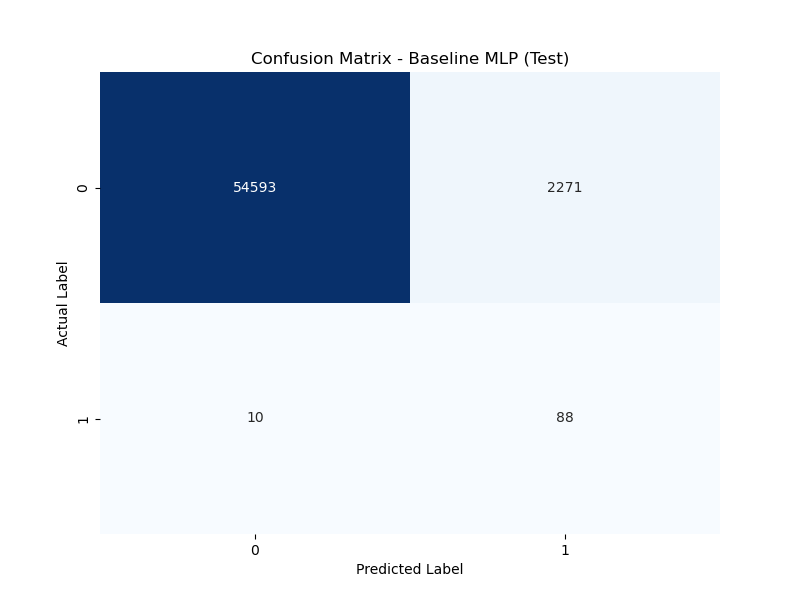

adv_pr_curve.png


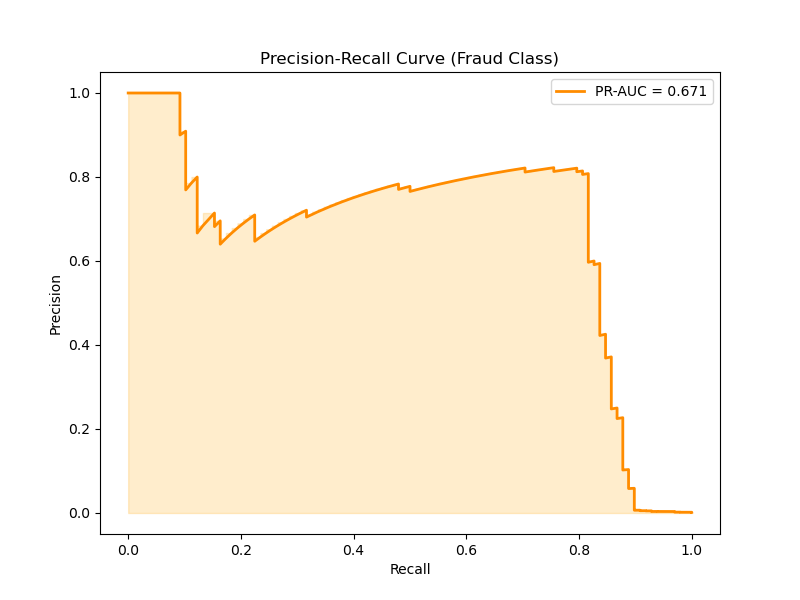

clean_confusion_matrix.png


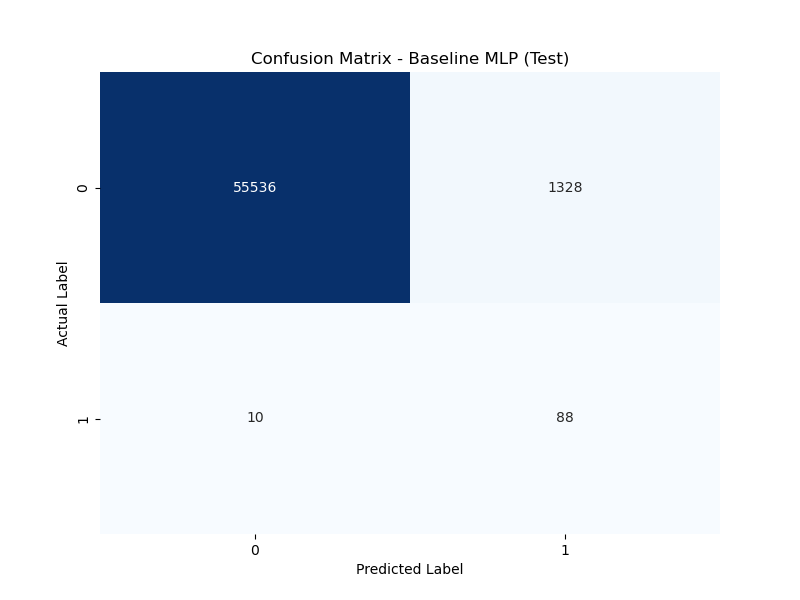

clean_pr_curve.png


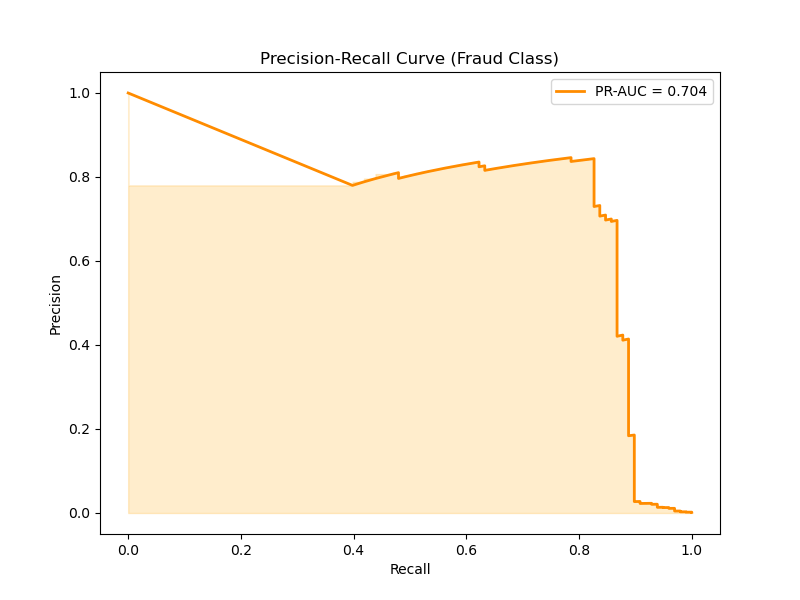

learning_curves.png


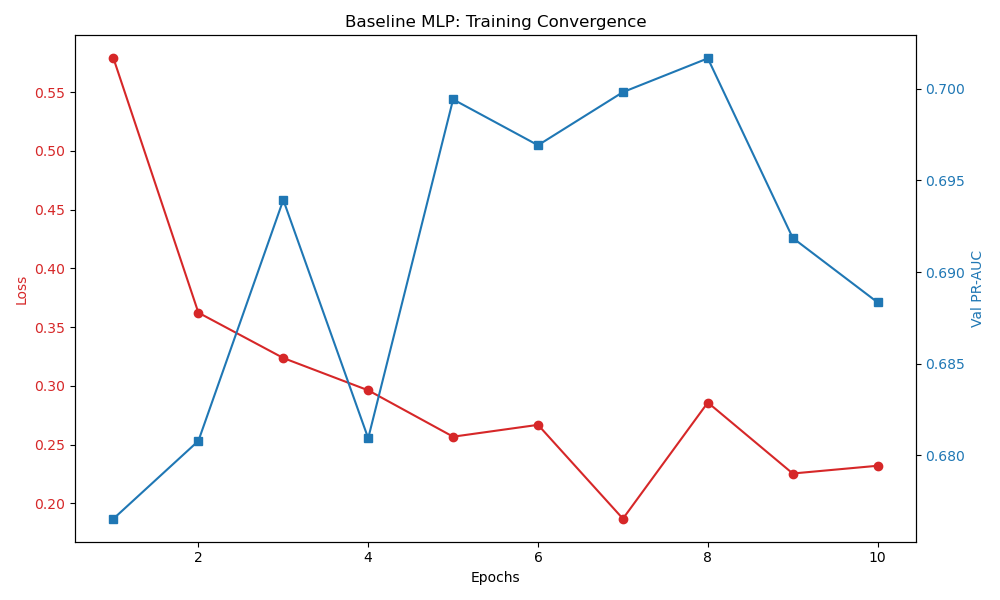

In [25]:
for file in os.listdir("adversarial_model"):
    if file.endswith(".png"):
        print(f"{file}")
        display(Image(filename=os.path.join("adversarial_model", file)))

## Privacy Protection (Confidentiality)

### The Attack: Membership Inference Attack (MIA)

In [8]:
!python -m src.privacy.mia_attack

Auditing model for Privacy leaks: baseline_model/mlp_baseline.pt

--- Privacy Audit Results ---
MIA Attack ROC-AUC: 0.4976
Status: PRIVACY PRESERVED


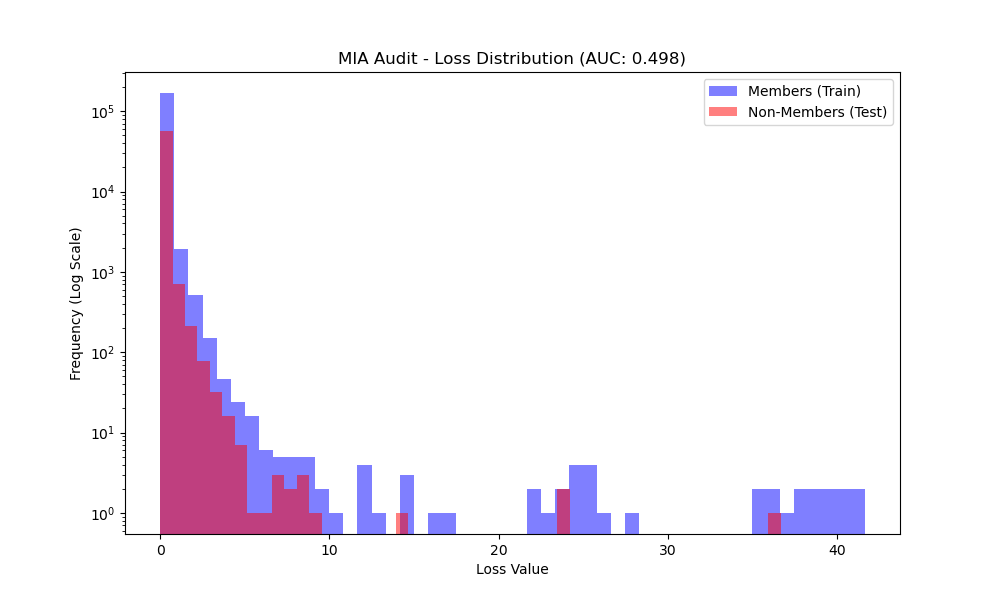

In [16]:
display(Image(filename='privacy_results/mia_distribution.png'))

### The Defense: Differential Privacy (DP-SGD)

In [18]:
!python -m src.privacy.dp_training 

Epoch 01 | Test PR-AUC: 0.0009 | Epsilon: 1.40
Epoch 02 | Test PR-AUC: 0.0018 | Epsilon: 1.64
Epoch 03 | Test PR-AUC: 0.2000 | Epsilon: 1.81
Epoch 04 | Test PR-AUC: 0.5637 | Epsilon: 1.95
Epoch 05 | Test PR-AUC: 0.6259 | Epsilon: 2.07
Epoch 06 | Test PR-AUC: 0.6645 | Epsilon: 2.18
Epoch 07 | Test PR-AUC: 0.6829 | Epsilon: 2.29
Epoch 08 | Test PR-AUC: 0.6845 | Epsilon: 2.39
Epoch 09 | Test PR-AUC: 0.6941 | Epsilon: 2.49
Epoch 10 | Test PR-AUC: 0.6977 | Epsilon: 2.58
Epoch 11 | Test PR-AUC: 0.6862 | Epsilon: 2.67
Epoch 12 | Test PR-AUC: 0.6901 | Epsilon: 2.75
Epoch 13 | Test PR-AUC: 0.7162 | Epsilon: 2.83
Epoch 14 | Test PR-AUC: 0.7350 | Epsilon: 2.92
Epoch 15 | Test PR-AUC: 0.7347 | Epsilon: 2.99

=== DP Model - Final Test Results ===
Accuracy             : 0.9988764439450862
Precision (weighted) : 0.9988011684145565
Recall (weighted)    : 0.9988764439450862
F1-score (weighted)  : 0.9986406206937771
Precision (macro)    : 0.9619641790520361
Recall (macro)       : 0.688749131475888
F1-sc

c:\Users\charl\anaconda3\Lib\site-packages\opacus\privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
c:\Users\charl\anaconda3\Lib\site-packages\opacus\accountants\analysis\rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


confusion_matrix.png


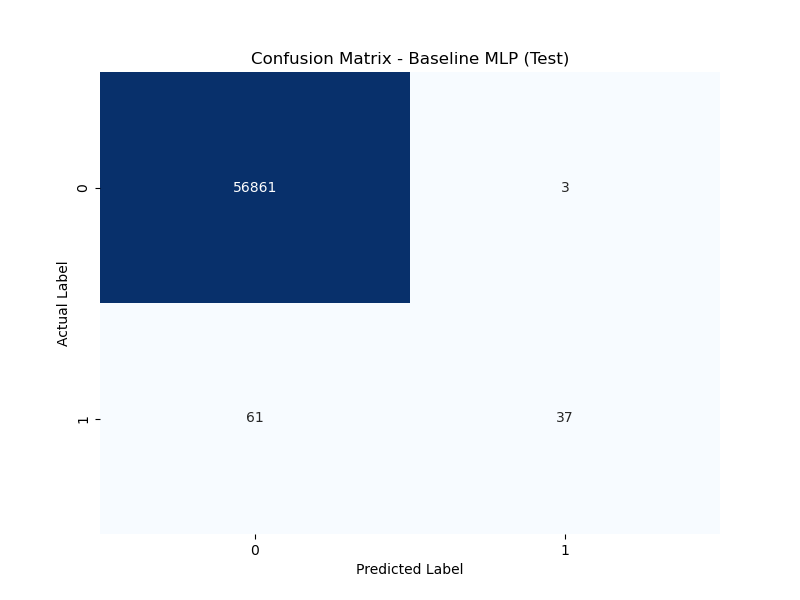

privacy_utility_tradeoff.png


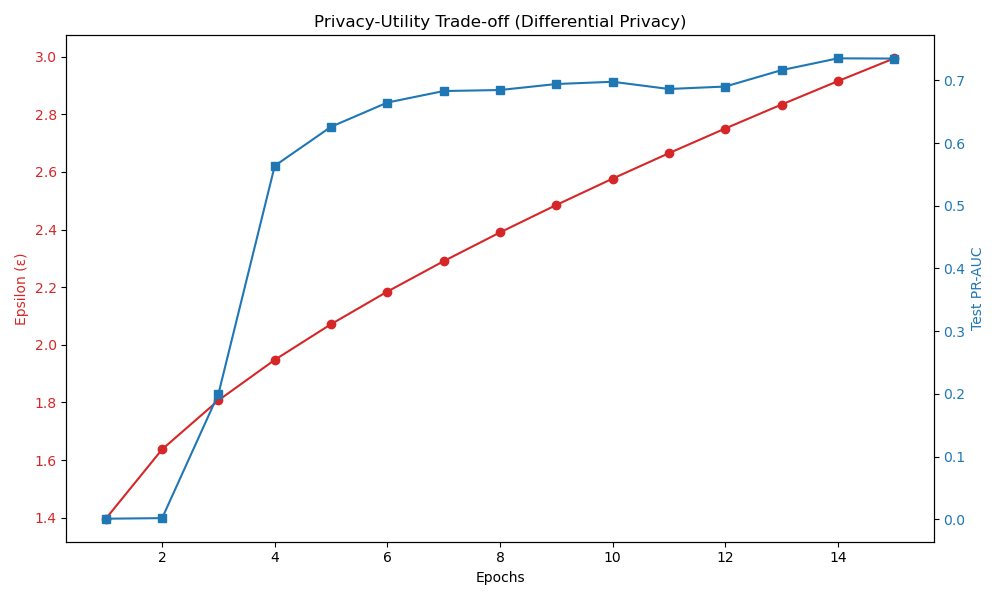

pr_curve.png


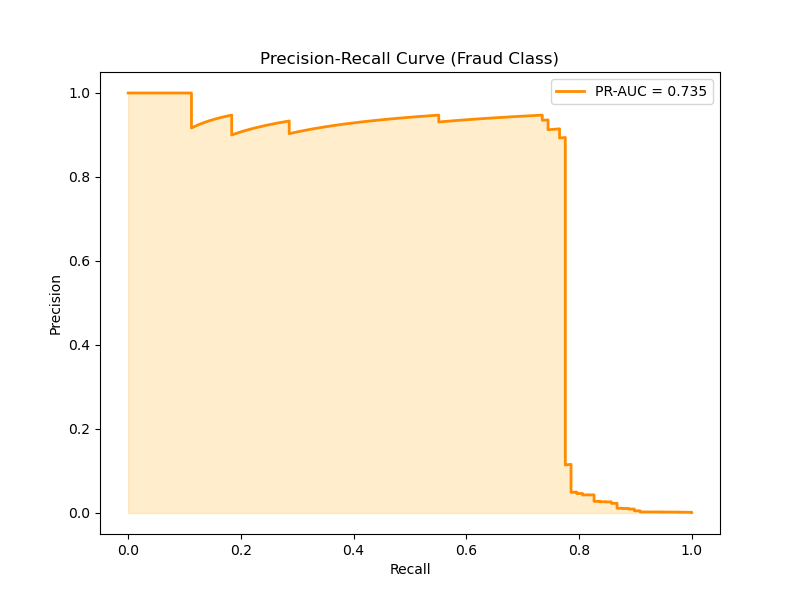

In [20]:
for file in os.listdir("dp_model"):
    if file.endswith(".png"):
        print(f"{file}")
        display(Image(filename=os.path.join("dp_model", file)))

## Fairness & Bias Assessment (Ethics)

### Assessment

### Mitigation: Reweighing

## Final Outcomes & Limitations